<a href="https://colab.research.google.com/github/fadeeva/Bayesian_Statistics_and_Quantitative_Finance/blob/main/01_Bayesian_estimation_of_volatility_with_unknown_drift/Bayesian_estimation_of_volatility_with_unknown_drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import datetime as dt
import yfinance as yf

import arviz as az
import pymc as pm

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Bayesian estimation of volatility with unknown drift

## Data

In [2]:
ticker = '^GSPC'
start = dt.datetime(2023, 1, 1)
interval = '1d'
data = yf.download(ticker, start=start, interval=interval, auto_adjust=True)
data.to_csv('data.csv')

[*********************100%***********************]  1 of 1 completed


In [3]:
df = pd.read_csv('data.csv', parse_dates=True, header=[0,1], index_col=0)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000


In [4]:
df.shape

(834, 5)

In [5]:
df['log_return'] = np.log(df['Close'].div(df['Close'].shift(1)))
df.dropna(axis=0, inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000,0.007511
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000,-0.011714
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000,0.022584
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000,-0.000768
2023-01-10,3919.250000,3919.830078,3877.290039,3888.570068,3851030000,0.006954


In [6]:
df.shape

(833, 6)

## Classical volatility estimation

In [7]:
df['log_return'].std()

0.009415452073096025

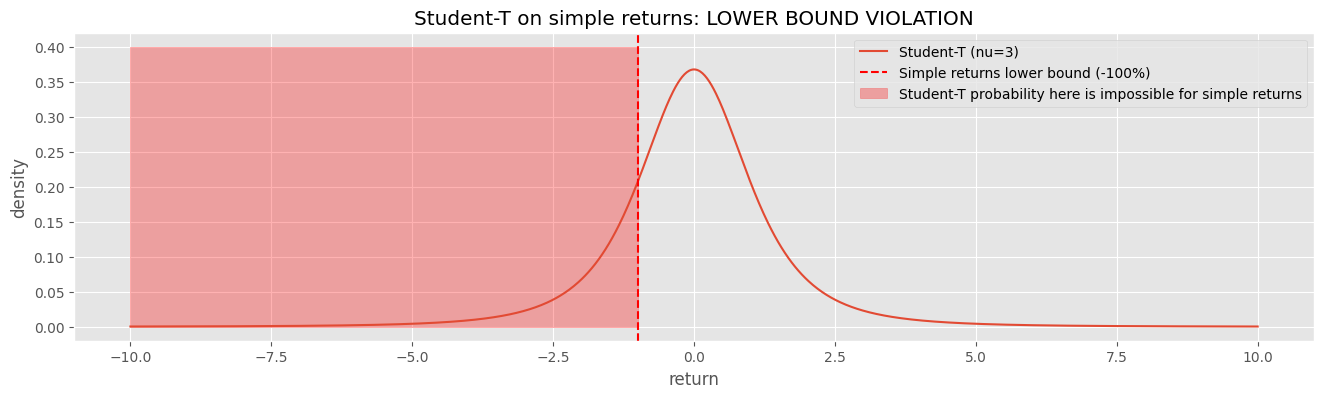

In [37]:
# Почему нужен log_return

from scipy.stats import t

# Студент-T определён на всей числовой прямой (−∞,+∞)
x = np.linspace(-10, 10, 1000)
plt.figure(figsize=(16, 4))
plt.plot(x, t.pdf(x, df=3), label='Student-T (nu=3)')

# Простые доходности ограничены снизу -1
plt.axvline(x=-1, color='r', linestyle='--', label='Simple returns lower bound (-100%)')
plt.fill_between([-10, -1], 0, 0.4, color='r', alpha=0.3, label='Student-T probability here is impossible for simple returns')

plt.xlabel('return')
plt.ylabel('density')
plt.title('Student-T on simple returns: LOWER BOUND VIOLATION')
plt.legend()

## Bayesian Estimation

In [38]:
with pm.Model() as volatility_student:
    mu = pm.Normal('mu', mu=0, sigma=.01)
    sigma = pm.HalfNormal('sigma', sigma=.05)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)  # degrees of freedom, tail thickness

    returns = pm.StudentT('returns', mu=mu, sigma=sigma, nu=nu, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

az.plot_trace(trace)

In [23]:
summary = az.summary(trace, hdi_prob=0.94)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001,0.000,0.001,0.002,0.00,0.00,6229.0,5880.0,1.0
nu,4.417,0.717,3.164,5.789,0.01,0.01,4938.0,4651.0,1.0
sigma,0.007,0.000,0.006,0.007,0.00,0.00,4848.0,5143.0,1.0


In [24]:
list(trace.posterior.data_vars)

['mu', 'nu', 'sigma']

In [25]:
mu_samples = trace.posterior['mu'].values.flatten()
sigma_samples = trace.posterior['sigma'].values.flatten()
nu_samples = trace.posterior['nu'].values.flatten()